# Universo 25 — Simulacao Baseada em Agentes

Recriacao computacional do experimento de **John B. Calhoun (1968)** utilizando
Modelagem Baseada em Agentes (ABM) com o framework **Mesa**.

O modelo reproduz as quatro fases do experimento original:

1. **Ajuste** (Dia 0-104) — Os primeiros agentes se estabelecem e comecam a se reproduzir
2. **Exploracao** (Dia 105-314) — Crescimento populacional exponencial (~620 ao fim)
3. **Estagnacao / Ralo Comportamental** (Dia 315-559) — Pico de ~2.200, colapso social
4. **Extincao / Os Lindos** (Dia 560-1588) — Ultimo nascimento no dia 600, decline gradual ate extincao

---

## 1. Parametros Globais

Todas as constantes que controlam o ambiente, biologia, comportamento e tempo da simulacao.

In [74]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===========================================================================
# PARAMETROS GLOBAIS
# ===========================================================================

# 1. Ambiente
GRID_WIDTH = 50
GRID_HEIGHT = 50
TOROIDAL = False
INITIAL_POPULATION = 8
MAX_SUPPORT_CAPACITY = 3840
RESOURCE_AVAILABILITY = 1.0
NEST_COUNT = 256
STRESSED_DENSITY_THRESHOLD = 12
FEEDING_STATIONS_COUNT = 16
STATION_MAX_OCCUPANCY = 25
TERRITORY_SIZE = 2
DOMINANCE_THRESHOLD = 0.6

# 2. Biologicos
MAX_AGE = 800
REPRODUCTIVE_AGE_START = 50
REPRODUCTIVE_AGE_END = 500
BASE_FERTILITY_RATE = 0.15
PREGNANCY_DURATION = 20
LITTER_SIZE_MIN = 3
LITTER_SIZE_MAX = 8
WEANING_PERIOD =21
NEST_CAPACITY = 15

# 3. Comportamento
STRESS_GAIN_RATE = 0.012
STRESS_RECOVERY_RATE = 0.012
STRESS_SPREAD_RATE = 0.010
ALPHA_THRESHOLD = 0.50
BEAUTIFUL_EMERGENCE_THRESHOLD = 0.50
HYPERSEXUALITY_THRESHOLD = 0.80
CANNIBALISM_PROBABILITY = 0.05
HUNGER_THRESHOLD = 0.5
CORPSE_DECAY_TURNS = 5
RESORPTION_PROBABILITY = 0.35
MATERNAL_AGGRESSION_THRESHOLD = 0.60
SOCIAL_DAMAGE_INHERITANCE = 0.25
SOCIAL_DAMAGE_BIRTH_FACTOR = 1.5
SOCIAL_DAMAGE_WEANING_RATE = 0.05
SOCIAL_DAMAGE_BEAUTIFUL_THRESHOLD = 0.50
BEAUTIFUL_MORTALITY_RATE = 0.0001
BEAUTIFUL_STRESS_MORTALITY = 0.00001

# 4. Cenario alternativo
ENVIRONMENTAL_ENRICHMENT = False

# 5. Escala populacional
COLONY_STRESS_DIVISOR = 2500

# 6. Tempo
STEPS = 1588

---

## 2. Esquema de Cores

Cada tipo de agente e elemento do ambiente tem uma cor associada para visualizacao.

In [75]:
AGENT_COLORS = {
    ('M', 'ALPHA'):    '#1E3A5F',
    ('M', 'BETA'):     '#6495ED',
    ('F', 'MATERNAL'): '#FF69B4',
    'PREGNANT':        '#FF1493',
    'PUPPY':           '#FFD700',
    'BEAUTIFUL':       '#D3D3D3',
    'DEAD':            '#8B4513',
}

GRID_COLORS_MAP = {
    'empty':        '#FFF5EE',
    'nest':         '#556B2F',
    'food_station': '#FF8C00',
}

---

## 3. Agente — MouseAgent

Cada camundongo e um agente com atributos independentes: sexo, idade, estresse,
status social (ALPHA, BETA, MATERNAL, BEAUTIFUL), fome, dano social, etc.

O ciclo de vida de cada agente a cada passo:
1. Se morto, apenas decrementa o timer do cadaver
2. Incrementa idade; morre se atingir `MAX_AGE`
3. Risco de morte para filhotes durante desmame (estresse da mae)
4. Acumula dano social durante o desmame
5. Atualiza estresse, tenta canibalismo, se alimenta, agressao materna, move
6. Comportamento especifico por sexo (defesa de territorio, acasalamento, gravidez)
7. Atualiza status social; hipersexualidade se estresse muito alto

In [76]:
class MouseAgent(mesa.Agent):
    # ---------------------------------------------------------------------
    # Inicializacao
    # ---------------------------------------------------------------------
    def __init__(self, model, sex, aggression_trait, sociability_trait,
                 social_learning_factor):
        super().__init__(model)
        self.sex = sex
        self.age = 100
        self.stress = 0.0
        self.social_status = 'ALPHA' if sex == 'M' else 'MATERNAL'
        self.is_pregnant = False
        self.gestation_timer = 0
        self.aggression_trait = aggression_trait
        self.sociability_trait = sociability_trait
        self.social_learning_factor = social_learning_factor
        self.alive = True
        self.mother_id = None
        self.mating_cooldown = 0
        self.hunger = 0.0
        self.corpse_timer = 0
        self.social_damage = 0.0
        self.aggressions = 0

    # ---------------------------------------------------------------------
    # Ciclo de vida principal (chamado a cada passo)
    # ---------------------------------------------------------------------
    def step(self):
        if not self.alive:
            if self.corpse_timer > 0:
                self.corpse_timer -= 1
                if self.corpse_timer <= 0:
                    self.model.grid.remove_agent(self)
            return

        self.aggressions = 0
        self.age += 1
        if self.age >= MAX_AGE:
            self.die()
            return

        if self.mating_cooldown > 0:
            self.mating_cooldown -= 1

        # Weaning - pup death risk from mother stress
        if self.age <= WEANING_PERIOD and self.mother_id is not None:
            mother = self._find_mother()
            if mother is not None and mother.stress > 0.4:
                if self.random.random() < mother.stress * 0.4:
                    self.die()
                    return

        # Social damage accumulates during weaning (permanent)
        if self.age <= WEANING_PERIOD:
            self.social_damage = min(1.0, self.social_damage + SOCIAL_DAMAGE_WEANING_RATE * self.model.colony_stress)

        self.update_stress()
        self.try_cannibalism()
        self.try_feed()
        self.maternal_aggression()
        self.move()

        if self.sex == 'M':
            if self.social_status == 'ALPHA':
                self.defend_territory()
            self.try_aggression()
            self.try_mate()
        else:
            if self.is_pregnant:
                self.update_pregnancy()
            else:
                self.try_mate()
            if self.stress > MATERNAL_AGGRESSION_THRESHOLD:
                self.try_aggression()

        self.update_status()

        if self.stress > HYPERSEXUALITY_THRESHOLD:
            self.hypersexuality()

    # ---------------------------------------------------------------------
    # Metodos auxiliares
    # ---------------------------------------------------------------------
    def _find_mother(self):
        for agent in self.model.agents:
            if (isinstance(agent, MouseAgent)
                    and agent.unique_id == self.mother_id and agent.alive):
                return agent
        return None

    def update_stress(self):
        ee = self.model.environmental_enrichment
        gain_mult = 0.65 if ee else 1.0
        rec_mult = 1.30 if ee else 1.0

        neighbors = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=True
        )
        nearby = 0
        stressed_nearby = 0.0
        for pos in neighbors:
            if not (0 <= pos[0] < GRID_WIDTH and 0 <= pos[1] < GRID_HEIGHT):
                continue
            cell = self.model.grid.get_cell_list_contents([pos])
            for a in cell:
                if isinstance(a, MouseAgent) and a is not self and a.alive:
                    nearby += 1
                    stressed_nearby += a.stress

        # Density gain (continuo - stress proporcional a densidade)
        density_ratio = nearby / STRESSED_DENSITY_THRESHOLD
        gain = STRESS_GAIN_RATE * min(1.0, density_ratio) * (1 - self.sociability_trait * 0.4) * gain_mult
        recovery = STRESS_RECOVERY_RATE * (0.6 + self.sociability_trait * 0.4) * rec_mult
        net_stress = gain - recovery
        self.stress = max(0.0, min(1.0, self.stress + net_stress))

        # Social contagion
        if stressed_nearby > 0:
            self.stress = min(1.0, self.stress + STRESS_SPREAD_RATE * stressed_nearby * 0.08)

        # Colony stress amplifies individual stress
        colony_factor = self.model.colony_stress
        self.stress = min(1.0, self.stress + colony_factor * 0.002)

        # Nest overcrowding penalty
        if self.pos in self.model.nest_positions:
            nest_occupants = sum(
                1 for a in self.model.grid.get_cell_list_contents([self.pos])
                if isinstance(a, MouseAgent) and a is not self and a.alive
            )
            if nest_occupants >= NEST_CAPACITY:
                overcrowding = (nest_occupants - NEST_CAPACITY + 1) * 0.005
                self.stress = min(1.0, self.stress + overcrowding)

    def move(self):
        obstacles = self.model.obstacles if self.model.environmental_enrichment else set()
        # Biased random walk: sometimes move toward nearest nest
        if self.random.random() < 0.10 and self.model.nest_positions:
            nest_arr = np.array(list(self.model.nest_positions))
            my_pos = np.array(self.pos)
            dists = np.sum((nest_arr - my_pos) ** 2, axis=1)
            nearest = nest_arr[dists.argmin()]
            dx = np.sign(nearest[0] - self.pos[0])
            dy = np.sign(nearest[1] - self.pos[1])
            target = (self.pos[0] + int(dx), self.pos[1] + int(dy))
            if (0 <= target[0] < GRID_WIDTH and 0 <= target[1] < GRID_HEIGHT
                    and target not in obstacles):
                self.model.grid.move_agent(self, target)
                return

        # Random walk
        neighbors = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        valid = [
            p for p in neighbors
            if 0 <= p[0] < GRID_WIDTH and 0 <= p[1] < GRID_HEIGHT
            and p not in obstacles
        ]
        if valid:
            self.model.grid.move_agent(self, self.random.choice(valid))

    def defend_territory(self):
        for dx in range(-TERRITORY_SIZE, TERRITORY_SIZE + 1):
            for dy in range(-TERRITORY_SIZE, TERRITORY_SIZE + 1):
                x = self.pos[0] + dx
                y = self.pos[1] + dy
                if not (0 <= x < GRID_WIDTH and 0 <= y < GRID_HEIGHT):
                    continue
                cell = self.model.grid.get_cell_list_contents([(x, y)])
                for agent in cell:
                    if (isinstance(agent, MouseAgent) and agent is not self
                            and agent.alive and agent.sex == 'M'
                            and agent.social_status == 'BETA'):
                        if self.random.random() < DOMINANCE_THRESHOLD:
                            self._push_agent(agent)

    def _push_agent(self, agent):
        neighbors = self.model.grid.get_neighborhood(
            agent.pos, moore=True, include_center=False
        )
        valid = [
            p for p in neighbors
            if 0 <= p[0] < GRID_WIDTH and 0 <= p[1] < GRID_HEIGHT
            and self.model.grid.is_cell_empty(p)
        ]
        if valid:
            self.model.grid.move_agent(agent, self.random.choice(valid))

    # ---------------------------------------------------------------------
    # Metodos de comportamento
    # ---------------------------------------------------------------------
    def try_cannibalism(self):
        if self.social_status == 'BEAUTIFUL':
            return
        cell = self.model.grid.get_cell_list_contents([self.pos])
        for other in cell:
            if (isinstance(other, MouseAgent) and other is not self
                    and not other.alive and other.corpse_timer > 0):
                colony = self.model.colony_stress
                p = CANNIBALISM_PROBABILITY + colony * 0.15
                if self.random.random() < p:
                    other.corpse_timer = 0
                    self.model.grid.remove_agent(other)
                    self.stress = max(0.0, self.stress - 0.02)
                    self.hunger = max(0.0, self.hunger - 0.3)
                    return

    def try_feed(self):
        resource_factor = 2.0 - RESOURCE_AVAILABILITY
        self.hunger = min(1.0, self.hunger + 0.02 * resource_factor)
        if self.hunger > HUNGER_THRESHOLD:
            self.stress = min(1.0, self.stress + 0.005)
        if self.pos in self.model.food_station_positions:
            cell = self.model.grid.get_cell_list_contents([self.pos])
            occupants = sum(
                1 for a in cell
                if isinstance(a, MouseAgent) and a is not self and a.alive
            )
            if occupants < STATION_MAX_OCCUPANCY:
                self.hunger = max(0.0, self.hunger - 0.5)
                self.stress = max(0.0, self.stress - 0.005)
            else:
                self.stress = min(1.0, self.stress + 0.01)

    def maternal_aggression(self):
        if self.sex != 'F' or self.social_status == 'BEAUTIFUL':
            return
        if self.stress <= MATERNAL_AGGRESSION_THRESHOLD:
            return
        cell = self.model.grid.get_cell_list_contents([self.pos])
        for other in cell:
            if (isinstance(other, MouseAgent) and other is not self
                    and other.alive and other.age <= WEANING_PERIOD
                    and other.mother_id == self.unique_id):
                if self.random.random() < self.stress * 0.3:
                    other.die()

    def try_mate(self):
        if self.sex == 'M' and self.social_status == 'BEAUTIFUL':
            return
        if self.sex == 'F' and (self.is_pregnant or self.social_status == 'BEAUTIFUL'):
            return
        if self.age < REPRODUCTIVE_AGE_START or self.age > REPRODUCTIVE_AGE_END:
            return
        if self.mating_cooldown > 0:
            return

        # Check in a 3-cell radius for mates
        for dx in range(-3, 4):
            for dy in range(-3, 4):
                if dx == 0 and dy == 0:
                    continue
                x = self.pos[0] + dx
                y = self.pos[1] + dy
                if not (0 <= x < GRID_WIDTH and 0 <= y < GRID_HEIGHT):
                    continue
                cell = self.model.grid.get_cell_list_contents([(x, y)])
                for a in cell:
                    if (isinstance(a, MouseAgent) and a is not self and a.alive
                            and a.sex != self.sex
                            and a.social_status != 'BEAUTIFUL'
                            and a.mating_cooldown == 0
                            and not (a.sex == 'F' and a.is_pregnant)
                            and a.age >= REPRODUCTIVE_AGE_START
                            and a.age <= REPRODUCTIVE_AGE_END):
                        female = self if self.sex == 'F' else a
                        social_penalty = max(0.01, 1 - female.social_damage * 0.9)
                        p_mate = BASE_FERTILITY_RATE * (1 - max(self.stress, female.stress) * 0.5) * social_penalty
                        if self.random.random() < p_mate:
                            if not female.is_pregnant:
                                female.is_pregnant = True
                                female.gestation_timer = PREGNANCY_DURATION
                                female.mating_cooldown = 15
                                if self.sex == 'M':
                                    self.mating_cooldown = 5
                            return

    def hypersexuality(self):
        if self.social_status == 'BEAUTIFUL':
            return
        for dx in range(-3, 4):
            for dy in range(-3, 4):
                if dx == 0 and dy == 0:
                    continue
                x = self.pos[0] + dx
                y = self.pos[1] + dy
                if not (0 <= x < GRID_WIDTH and 0 <= y < GRID_HEIGHT):
                    continue
                cell = self.model.grid.get_cell_list_contents([(x, y)])
                for agent in cell:
                    if (isinstance(agent, MouseAgent) and agent is not self
                            and agent.alive and agent.social_status != 'BEAUTIFUL'):
                        if self.random.random() < BASE_FERTILITY_RATE * 0.5:
                            female = self if self.sex == 'F' else agent
                            if (female.sex == 'F' and not female.is_pregnant
                                    and female.age >= REPRODUCTIVE_AGE_START
                                    and female.age <= REPRODUCTIVE_AGE_END):
                                female.is_pregnant = True
                                female.gestation_timer = PREGNANCY_DURATION // 2
                                female.mating_cooldown = 10

    # ---------------------------------------------------------------------
    # Metodos de ciclo de vida
    # ---------------------------------------------------------------------
    def try_aggression(self):
        if self.social_status == 'BEAUTIFUL':
            return
        neighbors = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=True
        )
        for pos in neighbors:
            if not (0 <= pos[0] < GRID_WIDTH and 0 <= pos[1] < GRID_HEIGHT):
                continue
            cell = self.model.grid.get_cell_list_contents([pos])
            for other in cell:
                if (isinstance(other, MouseAgent) and other is not self
                        and other.alive):
                    p_attack = self.stress * self.aggression_trait * 0.1
                    if self.random.random() < p_attack:
                        other.stress = min(1.0, other.stress + 0.003)
                        self.aggressions += 1
                        if self.random.random() < self.stress * 0.01:
                            other.die()

    def update_pregnancy(self):
        if self.stress > 0.4:
            if self.random.random() < self.stress * RESORPTION_PROBABILITY:
                self.is_pregnant = False
                self.gestation_timer = 0
                self.stress = min(1.0, self.stress + 0.05)
                self.mating_cooldown = 5
                return
        self.gestation_timer -= 1
        if self.gestation_timer <= 0:
            self.give_birth()

    def give_birth(self):
        litter_size = self.random.randint(LITTER_SIZE_MIN, LITTER_SIZE_MAX + 1)
        colony_stress = self.model.colony_stress

        weaning_penalty = colony_stress * 0.7 + self.stress * 0.2
        pup_survive = max(0.02, 1 - weaning_penalty)
        survivors = sum(
            1 for _ in range(litter_size) if self.random.random() < pup_survive
        )

        for _ in range(survivors):
            inherited_stress = colony_stress * 0.4 + self.stress * 0.2
            sex = 'M' if self.random.random() < 0.5 else 'F'

            child = MouseAgent(
                self.model, sex,
                self.random.random(),
                self.random.random(),
                self.random.random(),
            )
            child.age = 0
            child.stress = min(1.0, inherited_stress)
            child.mother_id = self.unique_id

            # Social damage: inherited + birth environment (PERMANENT)
            child.social_damage = min(1.0,
                SOCIAL_DAMAGE_BIRTH_FACTOR * colony_stress +
                SOCIAL_DAMAGE_INHERITANCE * self.social_damage
            )

            # Beautiful: traditional threshold OR social damage
            is_beautiful = False
            if child.social_damage >= SOCIAL_DAMAGE_BEAUTIFUL_THRESHOLD:
                is_beautiful = True
            elif colony_stress > BEAUTIFUL_EMERGENCE_THRESHOLD:
                beautiful_p = (colony_stress - BEAUTIFUL_EMERGENCE_THRESHOLD) / (1.0 - BEAUTIFUL_EMERGENCE_THRESHOLD)
                is_beautiful = self.random.random() < beautiful_p

            if is_beautiful:
                child.social_status = 'BEAUTIFUL'
                child.stress = child.stress * 0.2

            neighbors = self.model.grid.get_neighborhood(
                self.pos, moore=True, include_center=False
            )
            valid = [
                p for p in neighbors
                if 0 <= p[0] < GRID_WIDTH and 0 <= p[1] < GRID_HEIGHT
            ]
            pos = self.random.choice(valid) if valid else self.pos
            self.model.grid.place_agent(child, pos)
            self.model.total_births += 1

        self.is_pregnant = False

    def update_status(self):
        if self.social_status == 'BEAUTIFUL':
            if self.random.random() < BEAUTIFUL_MORTALITY_RATE + self.model.colony_stress * BEAUTIFUL_STRESS_MORTALITY:
                self.die()
            return
        if self.sex == 'M' and self.social_status == 'ALPHA':
            if self.stress > ALPHA_THRESHOLD:
                self.social_status = 'BETA'

    def die(self):
        if not self.alive:
            return
        self.alive = False
        self.model.total_deaths += 1
        self.corpse_timer = CORPSE_DECAY_TURNS

---

## 4. Modelo — Universe25Model

O modelo coordena o grid, cria os agentes iniciais, gerencia o estresse da colonia
e coleta dados a cada passo via `DataCollector`.

In [77]:
class Universe25Model(mesa.Model):
    def __init__(self, rng=None, environmental_enrichment=False):
        super().__init__(rng=rng)
        self.grid = mesa.space.MultiGrid(GRID_WIDTH, GRID_HEIGHT, torus=TOROIDAL)
        self.nest_positions = set()
        for _ in range(NEST_COUNT):
            self.nest_positions.add((
                self.rng.integers(GRID_WIDTH),
                self.rng.integers(GRID_HEIGHT),
            ))
        self.food_station_positions = set()
        for _ in range(FEEDING_STATIONS_COUNT):
            self.food_station_positions.add((
                self.rng.integers(GRID_WIDTH),
                self.rng.integers(GRID_HEIGHT),
            ))
        for _ in range(INITIAL_POPULATION):
            sex = 'M' if _ < 4 else 'F'
            agent = MouseAgent(
                self, sex,
                self.rng.random(),
                self.rng.random(),
                self.rng.random(),
            )
            agent.age = 100
            self.grid.place_agent(agent, (
                self.rng.integers(GRID_WIDTH),
                self.rng.integers(GRID_HEIGHT),
            ))
        self.total_births = 0
        self.total_deaths = 0
        self.total_aggressions = 0
        self.colony_stress = 0.0
        self.environmental_enrichment = environmental_enrichment
        self.obstacles = set()
        self.ee_step_counter = 0

        def pop_fn(m):
            return len([a for a in m.agents if isinstance(a, MouseAgent) and a.alive])

        def stress_fn(m):
            alive = [a for a in m.agents if isinstance(a, MouseAgent) and a.alive]
            return np.mean([a.stress for a in alive]) if alive else 0.0

        def count_fn(status):
            return lambda m: len(
                [a for a in m.agents if isinstance(a, MouseAgent)
                 and a.alive and a.social_status == status]
            )

        self.datacollector = mesa.DataCollector(
            model_reporters={
                'Population': pop_fn,
                'Mean Stress': stress_fn,
                'Colony Stress': 'colony_stress',
                'Total Births': 'total_births',
                'Total Deaths': 'total_deaths',
                'Aggression Count': lambda m: sum(
                    a.aggressions for a in m.agents
                    if isinstance(a, MouseAgent) and a.alive
                ),
                'ALPHA Count': count_fn('ALPHA'),
                'BETA Count': count_fn('BETA'),
                'MATERNAL Count': count_fn('MATERNAL'),
                'BEAUTIFUL Count': count_fn('BEAUTIFUL'),
            },
        )

    def step(self):
        alive = [a for a in self.agents if isinstance(a, MouseAgent) and a.alive]
        pop = len(alive)
        if pop > 0:
            mean_individual = np.mean([a.stress for a in alive])
            divisor = COLONY_STRESS_DIVISOR
            raw = min(1.0, pop / divisor * 0.3 + mean_individual * 0.7)
            self.colony_stress = max(raw, self.colony_stress * 0.9995)
        else:
            self.colony_stress = 0.0

        # Environmental enrichment
        if self.environmental_enrichment:
            self.ee_step_counter += 1
            if self.ee_step_counter % 50 == 0:
                n_obs = self.rng.integers(5, 11)
                for _ in range(n_obs):
                    ox = self.rng.integers(GRID_WIDTH)
                    oy = self.rng.integers(GRID_HEIGHT)
                    if ((ox, oy) not in self.nest_positions
                            and (ox, oy) not in self.food_station_positions):
                        self.obstacles.add((ox, oy))
            if self.ee_step_counter % 10 == 0:
                self.obstacles.clear()
            if self.ee_step_counter % 30 == 0:
                self.colony_stress = max(0.0, self.colony_stress - 0.02)
        else:
            self.obstacles.clear()

        self.agents.shuffle_do('step')
        self.datacollector.collect(self)

---

## 5. Visualizacao

Funcoes para desenhar a grade de agentes e gerar graficos de metricas.

In [78]:
def get_agent_color(agent):
    if not agent.alive:
        return AGENT_COLORS['DEAD']
    if agent.age < WEANING_PERIOD:
        return AGENT_COLORS['PUPPY']
    if agent.social_status == 'BEAUTIFUL':
        return AGENT_COLORS['BEAUTIFUL']
    if agent.sex == 'F' and agent.is_pregnant:
        return AGENT_COLORS['PREGNANT']
    return AGENT_COLORS.get(
        (agent.sex, agent.social_status),
        '#888888'
    )


def plot_grid(model, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    for x in range(GRID_WIDTH):
        for y in range(GRID_HEIGHT):
            color = GRID_COLORS_MAP['empty']
            if (x, y) in model.obstacles:
                color = '#2F2F2F'
            elif (x, y) in model.nest_positions:
                color = GRID_COLORS_MAP['nest']
            if (x, y) in model.food_station_positions:
                color = GRID_COLORS_MAP['food_station']
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1,
                facecolor=color, edgecolor='#dddddd', linewidth=0.3
            ))
    for agent in model.agents:
        if isinstance(agent, MouseAgent) and agent.alive:
            x, y = agent.pos
            ax.scatter(
                x + 0.5, y + 0.5,
                c=get_agent_color(agent), s=30,
                edgecolors='black', linewidth=0.3, zorder=5
            )
    legend_elements = [
        Patch(facecolor='#1E3A5F', label='Macho ALPHA'),
        Patch(facecolor='#6495ED', label='Macho BETA'),
        Patch(facecolor='#FF69B4', label='Femea MATERNAL'),
        Patch(facecolor='#FF1493', label='Femea grvida'),
        Patch(facecolor='#FFD700', label='Filhote'),
        Patch(facecolor='#D3D3D3', label='BEAUTIFUL'),
        Patch(facecolor='#556B2F', label='Ninho'),
        Patch(facecolor='#FF8C00', label='Comida'),
    ]
    if model.environmental_enrichment:
        legend_elements.append(Patch(facecolor='#2F2F2F', label='Obstaculo'))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=6,
              framealpha=0.85, edgecolor='#888888')
    ax.set_xlim(0, GRID_WIDTH)
    ax.set_ylim(0, GRID_HEIGHT)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax


def plot_metrics(model):
    data = model.datacollector.get_model_vars_dataframe()
    steps = data.index.values
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    ax = axes[0, 0]
    ax.plot(steps, data['Population'], color='#1E3A5F', linewidth=2)
    ax.axhline(y=2200, color='red', linestyle='--', alpha=0.5,
               label='Pico historico (~2200)')
    ax.axhline(y=3800, color='orange', linestyle=':', alpha=0.5,
               label='Capacidade maxima (3800)')
    ax.set_xlabel('Turno')
    ax.set_ylabel('Populacao')
    ax.set_title('Populacao Total')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(steps, data['Mean Stress'], color='#8B4513', linewidth=2,
            label='Estresse individual medio')
    ax.plot(steps, data['Colony Stress'], color='#FF6347', linewidth=1.5,
            linestyle='--', label='Estresse da colonia')
    ax.axhline(y=BEAUTIFUL_EMERGENCE_THRESHOLD, color='red', linestyle=':',
               alpha=0.5, label=f'Limiar BEAUTIFUL')
    ax.set_xlabel('Turno')
    ax.set_ylabel('Estresse')
    ax.set_title('Indices de Estresse')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    status_cols = ['ALPHA Count', 'BETA Count', 'MATERNAL Count', 'BEAUTIFUL Count']
    colors = ['#1E3A5F', '#6495ED', '#FF69B4', '#D3D3D3']
    ax.stackplot(steps, [data[c] for c in status_cols],
                 labels=['ALPHA', 'BETA', 'MATERNAL', 'BEAUTIFUL'],
                 colors=colors, alpha=0.8)
    ax.set_xlabel('Turno')
    ax.set_ylabel('Quantidade')
    ax.set_title('Distribuicao por Status Social')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(steps, data['Population'], color='#1E3A5F', linewidth=2,
            label='Simulacao')
    calhoun_days = [0, 104, 315, 560, 600, 736, 1471, 1588]
    calhoun_pops = [8, 50, 620, 2200, 2100, 2056, 100, 0]
    ax.plot(calhoun_days, calhoun_pops, 'o--', color='red', linewidth=1.5,
            markersize=4, label='Curva Alvo (Calhoun)')
    ax.fill_between(calhoun_days, calhoun_pops, alpha=0.1, color='red')
    ax.set_xlabel('Turno')
    ax.set_ylabel('Populacao')
    ax.set_title('Validacao - Curva Alvo de Calhoun')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[2, 0]
    if 'Aggression Count' in data.columns:
        ax.plot(steps, data['Aggression Count'], color='#DC143C', linewidth=1.5)
    ax.set_xlabel('Turno')
    ax.set_ylabel('Ataques por turno')
    ax.set_title('Agressao Total por Turno')
    ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    ax.plot(steps, data['Total Births'], color='#228B22', linewidth=1.5,
            label='Nascimentos')
    ax.plot(steps, data['Total Deaths'], color='#8B0000', linewidth=1.5,
            label='Mortes')
    ax.set_xlabel('Turno')
    ax.set_ylabel('Total acumulado')
    ax.set_title('Nascimentos vs Mortes (acumulado)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

---

## 6. Rodando a Simulacao

Criamos o modelo com `rng=42` (semente fixa para reprodutibilidade) e executamos
1588 passos, equivalente aos ~433 dias do experimento original de Calhoun.

In [79]:
%%time
model = Universe25Model(rng=42)

phase_checkpoints = [
    (0,    "Inicio"),
    (104,  "Fim Fase A"),
    (315,  "Fim Fase B"),
    (560,  "Pico"),
    (600,  "Ultimo nasc."),
    (736,  "Declinio"),
    (1471, "Quase ext."),
    (1588, "Extincao"),
]

snapshots = {}

for i in range(STEPS):
    model.step()
    for cp_step, cp_name in phase_checkpoints:
        if i == cp_step:
            snapshots[cp_step] = [
                (a.pos, get_agent_color(a))
                for a in model.agents
                if isinstance(a, MouseAgent) and a.alive
            ]

data = model.datacollector.get_model_vars_dataframe()
pop = data['Population']
print(f"Populacao final: {pop.iloc[-1]:.0f}")
print(f"Pico populacional: {pop.max():.0f} no passo {pop.idxmax()}")
print(f"Estresse medio final: {data['Mean Stress'].iloc[-1]:.3f}")
print(f"Estresse da colonia final: {data['Colony Stress'].iloc[-1]:.3f}")
print(f"Total de nascimentos: {data['Total Births'].iloc[-1]:.0f}")
print(f"Total de mortes: {data['Total Deaths'].iloc[-1]:.0f}")
print(f"Agentes BEAUTIFUL: {data['BEAUTIFUL Count'].iloc[-1]:.0f}")

print("\nSnapshots capturados:")
for cp_step, cp_name in phase_checkpoints:
    n = len(snapshots.get(cp_step, []))
    print(f"  Passo {cp_step:4d} ({cp_name:14s}): {n:5d} agentes")

Populacao final: 0
Pico populacional: 3715 no passo 408
Estresse medio final: 0.000
Estresse da colonia final: 0.000
Total de nascimentos: 6935
Total de mortes: 6943
Agentes BEAUTIFUL: 0

Snapshots capturados:
  Passo    0 (Inicio        ):     8 agentes
  Passo  104 (Fim Fase A    ):    16 agentes
  Passo  315 (Fim Fase B    ):  1528 agentes
  Passo  560 (Pico          ):  2856 agentes
  Passo  600 (Ultimo nasc.  ):  2642 agentes
  Passo  736 (Declinio      ):  2139 agentes
  Passo 1471 (Quase ext.    ):     0 agentes
  Passo 1588 (Extincao      ):     0 agentes
CPU times: user 1min 45s, sys: 788 ms, total: 1min 45s
Wall time: 1min 45s


---

## 7. Grade de Agentes — Todas as Fases

Evolucao espacial da colonia ao longo dos8 checkpoints do experimento.
Cada subplot mostra o estado da grade naquele momento da simulacao.

- Azul escuro: Macho ALPHA
- Azul claro: Macho BETA
- Rosa: Femea MATERNAL
- Rosa escuro: Femea gravid
- Amarelo: Filhote
- Cinza: BEAUTIFUL (Lindo)

Fundo bege = celulas vazias, verde = ninhos, laranja = estacoes de comida.

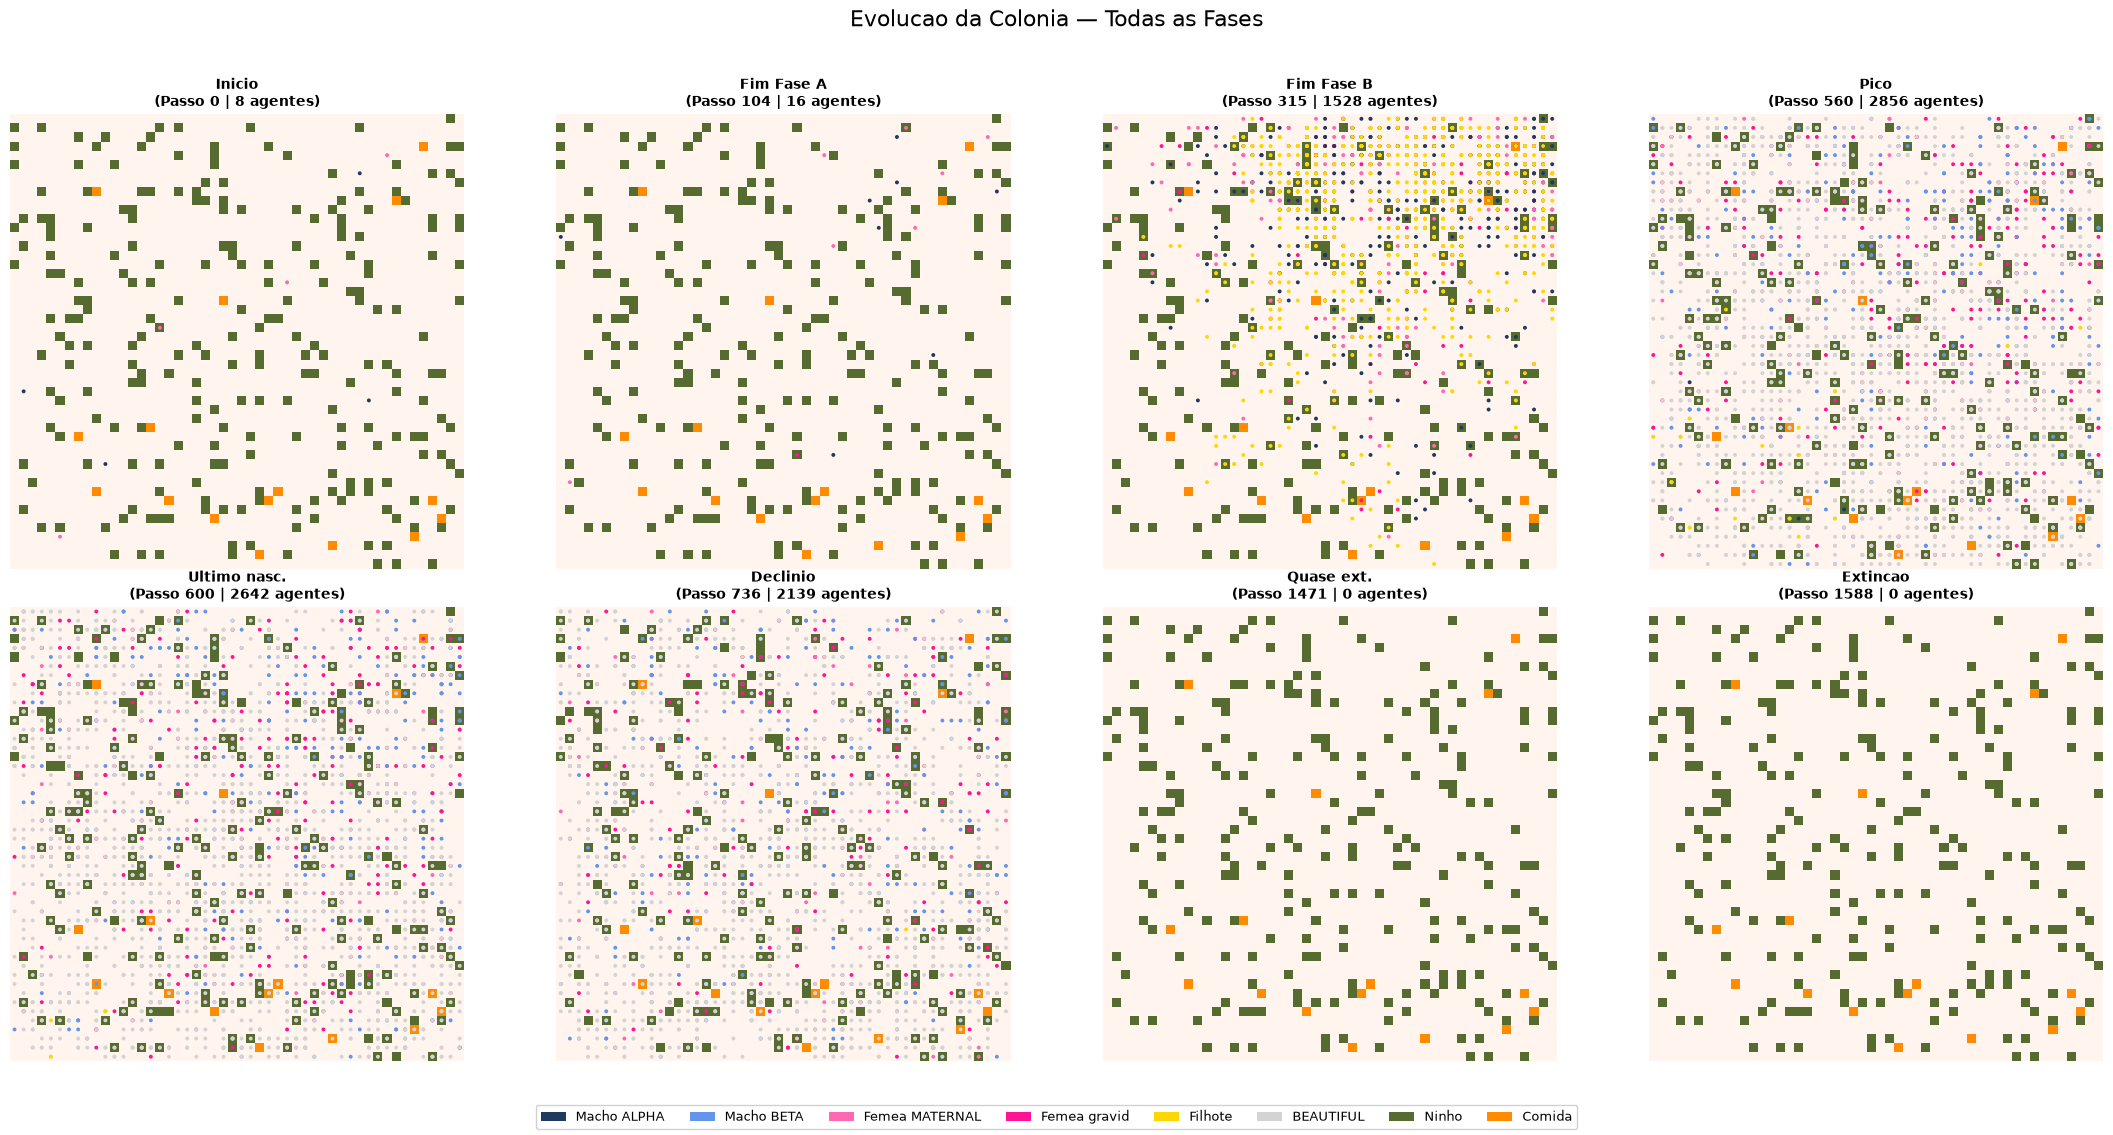

In [80]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))

for idx, (cp_step, cp_name) in enumerate(phase_checkpoints):
    ax = axes[idx // 4][idx % 4]

    # Fundo: ninhos (verde) e comida (laranja)
    for x in range(GRID_WIDTH):
        for y in range(GRID_HEIGHT):
            color = GRID_COLORS_MAP['empty']
            if (x, y) in model.nest_positions:
                color = GRID_COLORS_MAP['nest']
            if (x, y) in model.food_station_positions:
                color = GRID_COLORS_MAP['food_station']
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1,
                facecolor=color, edgecolor='none', linewidth=0
            ))

    # Agentes do snapshot
    n_agents = len(snapshots.get(cp_step, []))
    for pos, color in snapshots.get(cp_step, []):
        ax.scatter(pos[0]+0.5, pos[1]+0.5, c=color, s=8,
                   edgecolors='none', zorder=5)

    ax.set_title(f'{cp_name}\n(Passo {cp_step} | {n_agents} agentes)',
                 fontsize=10, fontweight='bold')
    ax.set_xlim(0, GRID_WIDTH)
    ax.set_ylim(0, GRID_HEIGHT)
    ax.set_aspect('equal')
    ax.axis('off')

# Legenda unica
legend_elements = [
    Patch(facecolor='#1E3A5F', label='Macho ALPHA'),
    Patch(facecolor='#6495ED', label='Macho BETA'),
    Patch(facecolor='#FF69B4', label='Femea MATERNAL'),
    Patch(facecolor='#FF1493', label='Femea gravid'),
    Patch(facecolor='#FFD700', label='Filhote'),
    Patch(facecolor='#D3D3D3', label='BEAUTIFUL'),
    Patch(facecolor='#556B2F', label='Ninho'),
    Patch(facecolor='#FF8C00', label='Comida'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=8,
           fontsize=9, framealpha=0.9)
plt.suptitle('Evolucao da Colonia — Todas as Fases', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

---

## 8. Metricas da Simulacao

Graficos da evolucao temporal: populacao, estresse, distribuicao por status social,
comparacao com a curva alvo de Calhoun, agressoes e nascimentos vs mortes.

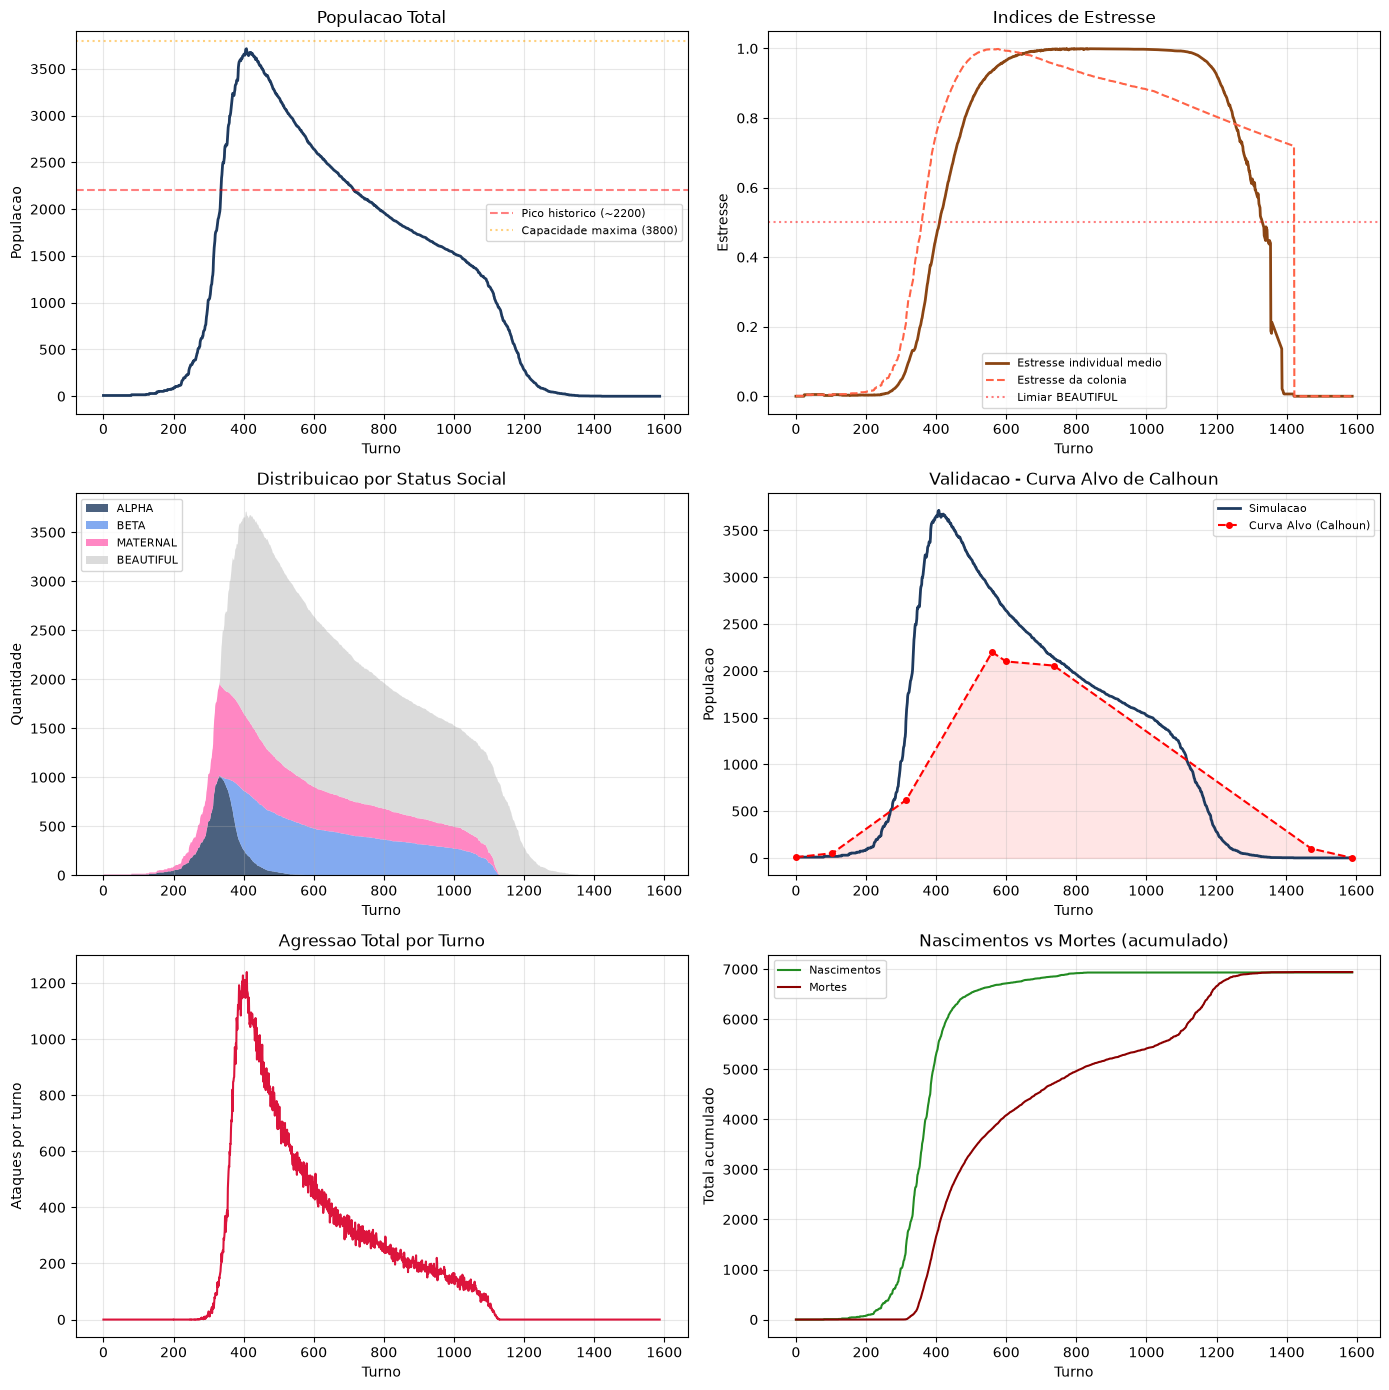

In [81]:
fig = plot_metrics(model)
plt.show()

---

## 9. Resumo das Fases

Populacao nos pontos-chave da simulacao comparada com o experimento original.

In [82]:
print("Fase               | Dia | Populacao | Alvo Calhoun |")
print("-" * 65)
checkpoints = [
    (0,    "Inicio",        8),
    (104,  "Fim Fase A",    50),
    (315,  "Fim Fase B",    620),
    (560,  "Pico",          2200),
    (600,  "Ultimo nasc.",  2100),
    (736,  "Declinio",      2056),
    (1471, "Quase ext.",    100),
    (1588, "Extincao",      0),
]
for d, name, target in checkpoints:
    if d < len(pop):
        sim = pop.iloc[d]
        if target > 0:
            pct = sim / target * 100
            match = "OK" if abs(pct - 100) < 25 else "~" if abs(pct - 100) < 50 else "X"
            print(f"{name:16s} | {d:4d} | {sim:6.0f}     | {target:4d}      | {pct:3.0f}% {match}")
        else:
            print(f"{name:16s} | {d:4d} | {sim:6.0f}     | {target:4d}      | --")

print()
print(f"Agentes BEAUTIFUL no final: {data['BEAUTIFUL Count'].iloc[-1]:.0f}")
print(f"Estresse da colonia no final: {data['Colony Stress'].iloc[-1]:.3f}")

Fase               | Dia | Populacao | Alvo Calhoun |
-----------------------------------------------------------------
Inicio           |    0 |      8     |    8      | 100% OK
Fim Fase A       |  104 |     16     |   50      |  32% X
Fim Fase B       |  315 |   1528     |  620      | 246% X
Pico             |  560 |   2856     | 2200      | 130% ~
Ultimo nasc.     |  600 |   2642     | 2100      | 126% ~
Declinio         |  736 |   2139     | 2056      | 104% OK
Quase ext.       | 1471 |      0     |  100      |   0% X

Agentes BEAUTIFUL no final: 0
Estresse da colonia no final: 0.000
